In [1]:
!pip -q install diffusers transformers accelerate safetensors sentencepiece scipy pillow

Generowanie obrazu WSEI

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recomme

model_index.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/372 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


  0%|          | 0/2 [00:00<?, ?it/s]

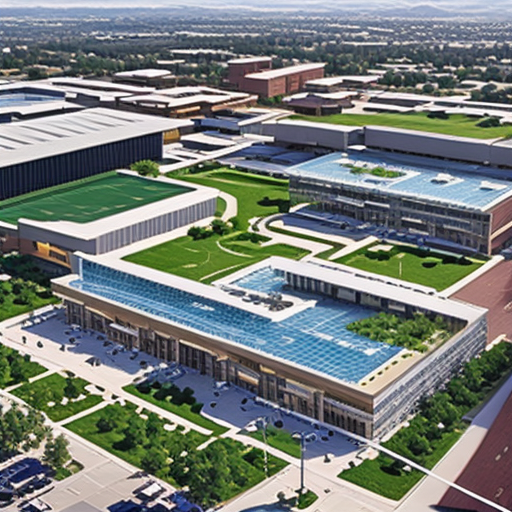

In [3]:
import torch
from diffusers import AutoPipelineForText2Image

device = "cuda" if torch.cuda.is_available() else "cpu"

pipe = AutoPipelineForText2Image.from_pretrained(
    "stabilityai/sd-turbo",
    torch_dtype=torch.float16 if device == "cuda" else torch.float32
).to(device)

prompt = "modern WSEI university campus, students, technology, innovative, realistic"
# Wszystkie 3 osobno generuje (pojedyńczo w każdym przebiegu)
#prompt = "WSEI campus in cyberpunk style, neon lights, futuristic students"
#prompt = "students studying at WSEI, modern classroom, laptops, academic atmosphere"
image = pipe(prompt, num_inference_steps=2, guidance_scale=0.0).images[0]

image.save("wsei1.png")
image

Opis Obrazu

In [4]:
from transformers import BlipProcessor, BlipForConditionalGeneration

processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base").to(device)

inputs = processor(images=image, return_tensors="pt").to(device)
out = model.generate(**inputs)

caption = processor.decode(out[0], skip_special_tokens=True)
print(caption)

preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

the new campus at the university of arizona


Generuj opis obrazu

  0%|          | 0/2 [00:00<?, ?it/s]

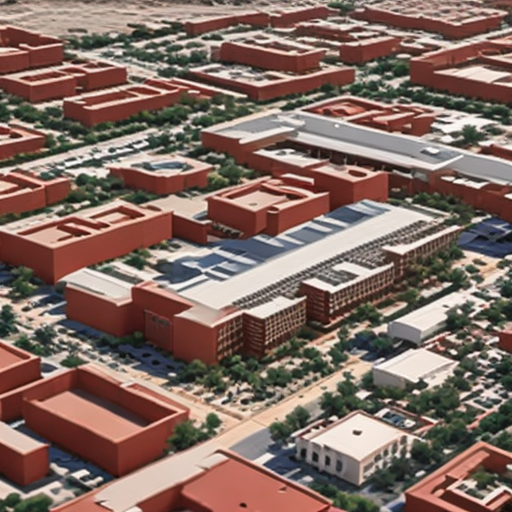

In [5]:
image2 = pipe(caption, num_inference_steps=2, guidance_scale=0.0).images[0]

image2.save("wsei2.png")
image2

Generowanie muzyki


In [1]:
import torch, gc
from transformers import AutoProcessor, MusicgenForConditionalGeneration
import scipy.io.wavfile as wavfile
import numpy as np

gc.collect()
torch.cuda.empty_cache()

device = "cuda" if torch.cuda.is_available() else "cpu"

processor_music = AutoProcessor.from_pretrained("facebook/musicgen-small")

model_music = MusicgenForConditionalGeneration.from_pretrained(
    "facebook/musicgen-small",
    torch_dtype=torch.float16 if device == "cuda" else torch.float32,
    low_cpu_mem_usage=True
).to(device)

prompt_music = "promotional university music, WSEI, inspiring, clean, electronic"
# Wszystkie 3 osobno generuje (pojedyńczo w każdym przebiegu)
#prompt_music = "corporate university promotional music, inspiring, energetic, clean"
#prompt_music = "chill student life music, ambient electronic, relaxed studying
inputs = processor_music(text=[prompt_music], return_tensors="pt", padding=True).to(device)

with torch.no_grad():
    audio_values = model_music.generate(
        **inputs,
        max_new_tokens=128
    )

audio = audio_values[0, 0].cpu().numpy()
sampling_rate = model_music.config.audio_encoder.sampling_rate
wavfile.write("music_short.wav", sampling_rate, (audio * 32767).astype(np.int16))
print("Zapisano music_short.wav")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/275 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/2.36G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/611 [00:00<?, ?it/s]

MusicgenForConditionalGeneration LOAD REPORT from: facebook/musicgen-small
Key                                           | Status     |  | 
----------------------------------------------+------------+--+-
decoder.model.decoder.embed_positions.weights | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/224 [00:00<?, ?B/s]

Zapisano music_short.wav


Obraz z muzyki

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/372 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


  0%|          | 0/2 [00:00<?, ?it/s]

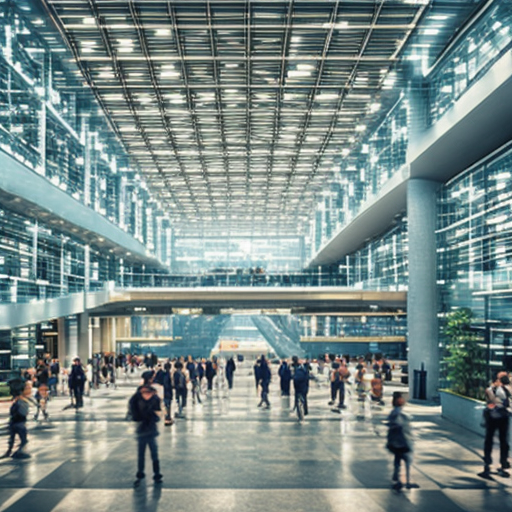

In [3]:
import torch
from diffusers import AutoPipelineForText2Image

device = "cuda" if torch.cuda.is_available() else "cpu"

pipe = AutoPipelineForText2Image.from_pretrained(
    "stabilityai/sd-turbo",
    torch_dtype=torch.float16 if device == "cuda" else torch.float32
).to(device)
prompt_from_music = "futuristic university campus, students, electronic ambient atmosphere, modern education"
# Wszystkie 3 osobno generuje (pojedyńczo w każdym przebiegu)
#prompt_from_music = "dark cyberpunk university, neon lights, futuristic students, electronic atmosphere"
#prompt_from_music = "creative university campus, students collaborating, warm light, modern architecture, artistic atmosphere, inspired by uplifting electronic music, innovation and technology"
image3 = pipe(prompt_from_music, num_inference_steps=2, guidance_scale=0.0).images[0]

image3.save("wsei3.png")
image3

Opis końcowy

In [6]:
import torch
from transformers import BlipProcessor, BlipForConditionalGeneration

device = "cuda" if torch.cuda.is_available() else "cpu"

processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-base"
).to(device)
inputs = processor(images=image3, return_tensors="pt").to(device)
out = model.generate(**inputs)

final_caption = processor.decode(out[0], skip_special_tokens=True)
print(final_caption)

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

a large building with many people walking around it


Pobranie plików

In [10]:
import os

for f in os.listdir("."):
    print(f)
from google.colab import files

files.download("wsei1.png")
files.download("wsei2.png")
files.download("wsei3.png")
files.download("music_short.wav")

.config
wsei2.png
wsei3.png
music_short.wav
wsei1.png
sample_data


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>